# Formula 1 Data Mining Final Project

**Aayush Upadhyay**  
**CSCE 676 Data Mining, Spring 2026**

## Collaboration Declaration

1. **Collaborators:** None
2. **Web sources:** Ergast Developer API documentation, Kaggle Formula 1 World Championship dataset page, scikit-learn documentation, lifelines documentation, mlxtend documentation
3. **AI tools:** Used Claude for debugging and formatting
4. **Citations:** Ergast Developer API, scikit-learn, lifelines, mlxtend

## Project Overview

This project uses historical Formula 1 race data from 1950 through 2022 to study how racing outcomes, pit stop strategies, and reliability patterns have changed across eras. I focused on three data mining questions: whether F1 seasons naturally cluster into competitive eras, what pit stop strategy patterns are associated with strong finishes, and what factors affect the risk of a driver not finishing a race.

The dataset is useful for this kind of project because it is relational, historical, and structured around events that have clear outcomes. Each race connects drivers, constructors, circuits, finishing positions, status codes, and pit stop records. That makes it possible to combine clustering, classification, association rule mining, and survival analysis in one coherent project.

## Research Questions

**RQ1:** Can Formula 1 seasons be clustered into distinct competitive eras, and does adding era information improve race outcome prediction?

**RQ2:** What frequent pit stop strategy patterns are associated with top finishes, and do those patterns differ between street and permanent circuits?

**RQ3:** What risk factors are associated with not finishing a race, and how has the survival landscape changed across Formula 1 eras?

These questions were selected because they cover multiple kinds of data mining tasks. RQ1 combines unsupervised clustering with supervised classification. RQ2 uses frequent itemset mining and association rules. RQ3 uses survival analysis as the beyond-course method because DNF is naturally a time-to-event problem rather than just a yes-or-no classification problem.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("data")
RACES_COLUMNS = [
    "raceId", "year", "round", "circuitId", "name", "date", "time", "url",
    "fp1_date", "fp1_time", "fp2_date", "fp2_time", "fp3_date", "fp3_time",
    "quali_date", "quali_time", "sprint_date", "sprint_time"
]

tables = {}
for file_path in sorted(DATA_DIR.glob("*.csv")):
    name = file_path.stem
    if name == "races":
        df = pd.read_csv(file_path, na_values=["\\N", ""], header=0, names=RACES_COLUMNS)
    else:
        df = pd.read_csv(file_path, na_values=["\\N", ""])
    for col in df.columns:
        if col.endswith("Id") or col in ["year", "grid", "positionOrder", "points", "laps", "lap", "stop"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    tables[name] = df

races = tables["races"]
results = tables["results"]
drivers = tables["drivers"]
constructors = tables["constructors"]
circuits = tables["circuits"]
pit_stops = tables["pit_stops"]
status = tables["status"]

summary = pd.DataFrame(
    [(name, df.shape[0], df.shape[1]) for name, df in sorted(tables.items())],
    columns=["table", "rows", "columns"]
)
summary

,table,rows,columns
0,circuits,79,9
1,constructor_results,11960,5
2,constructor_standings,12721,7
3,constructors,211,5
4,driver_standings,33435,7
5,drivers,854,9
6,lap_times,515715,6
7,pit_stops,8887,7
8,qualifying,9155,9
9,races,1079,18


## Data Preparation

The project uses the Formula 1 World Championship dataset, originally sourced from Ergast. In this repo, the committed data folder contains 13 CSV tables: races, results, drivers, constructors, circuits, pit stops, qualifying, standings, sprint results, seasons, and status codes. The data spans 1,079 races from 1950 through 2022.

The main engineered variable used across the project is `is_dnf`, which marks a result as a did-not-finish event unless the status is `Finished` or a classified finish such as `+1 Lap`. This matches the way F1 records drivers who are still running at the end of the race even if they are laps down.

In [2]:
def is_dnf(status_text):
    if pd.isna(status_text):
        return 1
    status_value = str(status_text)
    if status_value == "Finished" or status_value.startswith("+"):
        return 0
    return 1

race_results = results.merge(races[["raceId", "year", "circuitId"]], on="raceId")
race_results = race_results.merge(status, on="statusId")
race_results["is_dnf"] = race_results["status"].apply(is_dnf).astype(int)

project_overview = pd.DataFrame({
    "metric": [
        "seasons", "races", "driver-race results", "drivers", "constructors",
        "circuits", "pit stop rows", "overall DNF rate"
    ],
    "value": [
        races["year"].nunique(), races["raceId"].nunique(), len(results),
        drivers["driverId"].nunique(), constructors["constructorId"].nunique(),
        circuits["circuitId"].nunique(), len(pit_stops), f"{race_results['is_dnf'].mean():.1%}"
    ]
})
project_overview

,metric,value
0,seasons,73
1,races,1079
2,driver-race results,25420
3,drivers,854
4,constructors,211
5,circuits,79
6,pit stop rows,8887
7,overall DNF rate,44.9%


## RQ1: Clustering Seasons and Predicting Race Outcomes

For the first question, I represented each season with aggregate features: number of races, number of drivers, number of constructors, DNF rate, average grid and finish position, points spread, maximum points, and number of unique winners. These features describe the structure of a season without directly forcing the model to group years by calendar order.

After clustering seasons, I used the cluster label as an era feature in top-five finish prediction. The baseline model uses grid position, year, constructor, driver, and circuit. The era-aware model adds the cluster label.

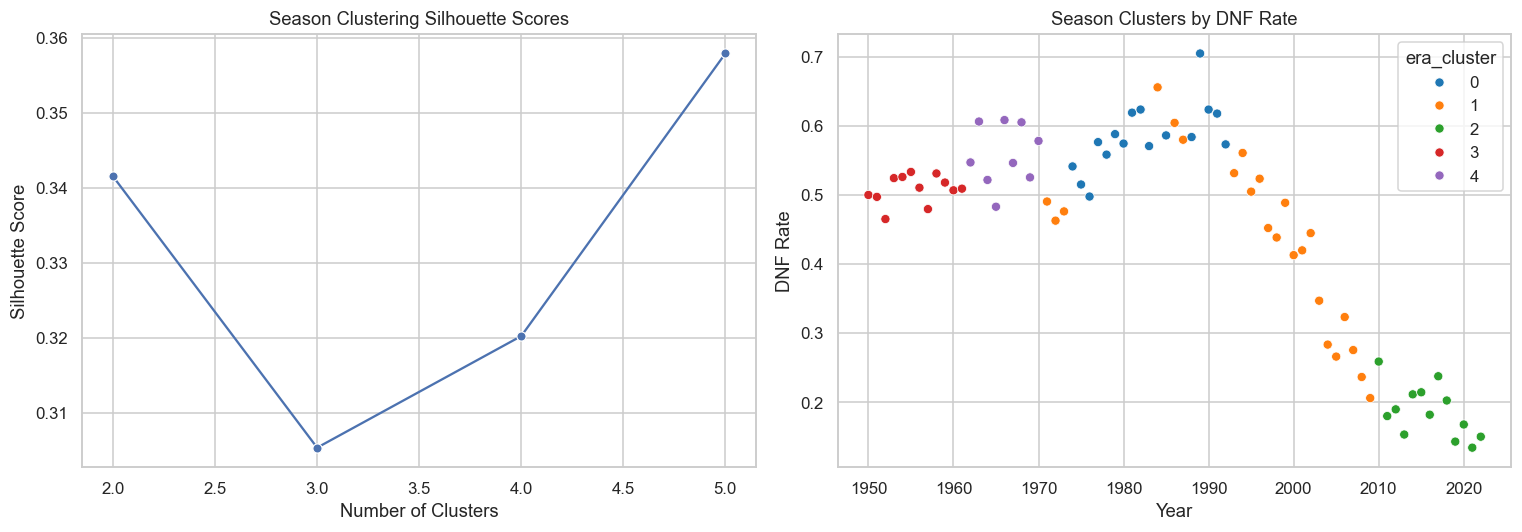

Cluster summary


,start_year,end_year,seasons,avg_dnf_rate,avg_unique_winners
era_cluster,,,,,
0,1974,1992,16,0.585,6.875
1,1971,2009,23,0.434,5.087
2,2010,2022,13,0.186,4.615
3,1950,1961,12,0.508,4.667
4,1962,1970,9,0.558,5.111


Prediction results


,model,baseline_macro_f1,baseline_std,era_macro_f1,era_std,era_delta
0,Random Forest,0.714,0.005,0.715,0.005,0.001
1,Gradient Boosting,0.724,0.006,0.723,0.007,-0.001


In [3]:
season_features = race_results.groupby("year").agg(
    n_races=("raceId", "nunique"),
    n_drivers=("driverId", "nunique"),
    n_constructors=("constructorId", "nunique"),
    dnf_rate=("is_dnf", "mean"),
    avg_grid=("grid", "mean"),
    avg_finish=("positionOrder", "mean"),
    points_std=("points", "std"),
    points_max=("points", "max")
).reset_index()

unique_winners = race_results[race_results["positionOrder"] == 1].groupby("year")["driverId"].nunique().reset_index(name="unique_winners")
season_features = season_features.merge(unique_winners, on="year", how="left").fillna({"unique_winners": 0})

feature_cols = [
    "n_races", "n_drivers", "n_constructors", "dnf_rate", "avg_grid",
    "avg_finish", "points_std", "points_max", "unique_winners"
]
X_season = StandardScaler().fit_transform(season_features[feature_cols])

silhouette_rows = []
for k in range(2, 6):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_season)
    silhouette_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_season, labels),
        "smallest_cluster": pd.Series(labels).value_counts().min()
    })

silhouette_df = pd.DataFrame(silhouette_rows)
chosen_k = silhouette_df.sort_values(["silhouette", "smallest_cluster"], ascending=False).iloc[0]["k"].astype(int)
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
season_features["era_cluster"] = kmeans.fit_predict(X_season)

cluster_summary = season_features.groupby("era_cluster").agg(
    start_year=("year", "min"),
    end_year=("year", "max"),
    seasons=("year", "count"),
    avg_dnf_rate=("dnf_rate", "mean"),
    avg_unique_winners=("unique_winners", "mean")
).round(3)

ml_data = race_results.merge(season_features[["year", "era_cluster"]], on="year")
ml_data = ml_data.dropna(subset=["grid", "positionOrder", "constructorId", "driverId", "circuitId"])
ml_data = ml_data[ml_data["grid"] > 0].copy()
ml_data["top5"] = (ml_data["positionOrder"] <= 5).astype(int)

base_features = ml_data[["grid", "year", "constructorId", "driverId", "circuitId"]].astype(float)
era_features = ml_data[["grid", "year", "constructorId", "driverId", "circuitId", "era_cluster"]].astype(float)
y_top5 = ml_data["top5"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
}

model_rows = []
for model_name, model in models.items():
    baseline_scores = cross_val_score(model, base_features, y_top5, cv=cv, scoring="f1_macro")
    era_scores = cross_val_score(model, era_features, y_top5, cv=cv, scoring="f1_macro")
    model_rows.append({
        "model": model_name,
        "baseline_macro_f1": baseline_scores.mean(),
        "baseline_std": baseline_scores.std(),
        "era_macro_f1": era_scores.mean(),
        "era_std": era_scores.std(),
        "era_delta": era_scores.mean() - baseline_scores.mean()
    })

model_results = pd.DataFrame(model_rows).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=silhouette_df, x="k", y="silhouette", marker="o", ax=axes[0])
axes[0].set_title("Season Clustering Silhouette Scores")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Silhouette Score")

plot_seasons = season_features.sort_values("year")
sns.scatterplot(data=plot_seasons, x="year", y="dnf_rate", hue="era_cluster", palette="tab10", ax=axes[1])
axes[1].set_title("Season Clusters by DNF Rate")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("DNF Rate")
plt.tight_layout()
plt.show()

print("Cluster summary")
display(cluster_summary)
print("Prediction results")
display(model_results)

### RQ1 Interpretation

The season clusters show that the data does separate F1 history into meaningful regimes. The biggest split is between modern, lower-DNF seasons and older seasons where reliability was much worse. This matches the sport historically: newer cars are much more reliable, race operations are more standardized, and the calendar is larger.

The prediction results are more modest. Adding the cluster label changes macro-F1 only slightly. My interpretation is that era matters, but much of that signal is already captured by year, constructor, driver, and grid position. Grid position remains the strongest predictor of a top-five finish, so era-aware modeling is useful context but not a dramatic improvement by itself.

## RQ2: Pit Stop Strategy Association Rules

Pit stop data is available only for the modern portion of the dataset, so this analysis focuses on races with recorded pit stops. Each driver-race entry is treated like a basket with four item types: number of stops, first stop timing, finish bucket, and circuit type.

The finish buckets are podium, top five, top ten, and outside the top ten. First stop timing is grouped into lap windows. Circuit type is simplified into street circuits and permanent circuits using a small domain-informed list of street venues.

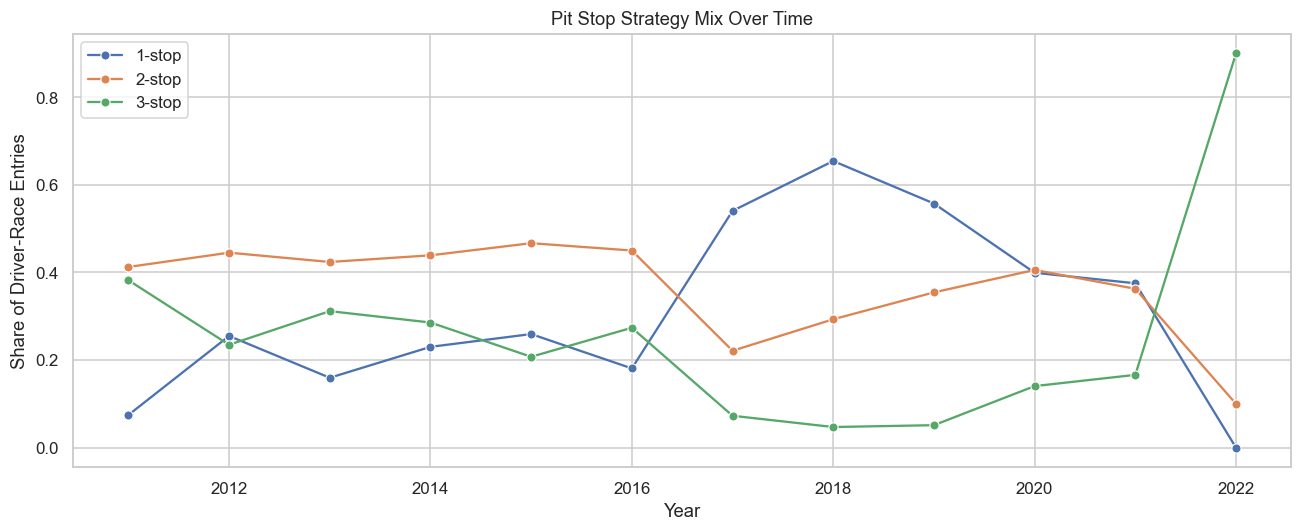

Driver-race pit stop transactions: 4,311
Apriori itemsets at 3% support: 114
FP-Growth itemsets at 3% support: 114
Association rules with lift above 1.0: 264


,antecedents,consequents,support,confidence,lift
0,"circuit_permanent, finish_top10, first_lap26+",1-stop,0.035,0.829,2.534
1,1-stop,"circuit_permanent, finish_top10, first_lap26+",0.035,0.106,2.534
2,"1-stop, finish_top10",first_lap26+,0.042,0.479,2.519
3,first_lap26+,"1-stop, finish_top10",0.042,0.223,2.519
4,"1-stop, finish_top10","circuit_permanent, first_lap26+",0.035,0.393,2.504
5,"circuit_permanent, first_lap26+","1-stop, finish_top10",0.035,0.222,2.504
6,"finish_top10, first_lap26+",1-stop,0.042,0.810,2.476
7,1-stop,"finish_top10, first_lap26+",0.042,0.130,2.476
8,"1-stop, circuit_permanent, finish_top10",first_lap26+,0.035,0.466,2.449
9,first_lap26+,"1-stop, circuit_permanent, finish_top10",0.035,0.183,2.449


In [4]:
pit_races = pit_stops.merge(races[["raceId", "year", "circuitId"]], on="raceId")
pit_races = pit_races.merge(circuits[["circuitId", "circuitRef", "name"]], on="circuitId")

stops_per_driver_race = pit_races.groupby(["raceId", "year", "driverId", "circuitRef"]).agg(
    n_stops=("stop", "max"),
    first_stop_lap=("lap", "min")
).reset_index()

stops_per_driver_race = stops_per_driver_race.merge(
    results[["raceId", "driverId", "positionOrder"]], on=["raceId", "driverId"]
)

stops_per_driver_race["finish_bucket"] = pd.cut(
    stops_per_driver_race["positionOrder"],
    bins=[0, 3, 5, 10, 50],
    labels=["podium", "top5", "top10", "outside_top10"]
)

stops_per_driver_race["first_stop_bucket"] = pd.cut(
    stops_per_driver_race["first_stop_lap"],
    bins=[0, 10, 15, 20, 25, 80],
    labels=["lap1-10", "lap11-15", "lap16-20", "lap21-25", "lap26+"]
)

street_circuits = {"monaco", "marina_bay", "baku", "vegas", "valencia", "jeddah", "albert_park"}
stops_per_driver_race["circuit_type"] = np.where(
    stops_per_driver_race["circuitRef"].isin(street_circuits), "street", "permanent"
)

baskets = stops_per_driver_race.dropna(subset=["finish_bucket", "first_stop_bucket"]).copy()
baskets["stop_strategy"] = baskets["n_stops"].astype(int).astype(str) + "-stop"
baskets["first_stop_str"] = "first_" + baskets["first_stop_bucket"].astype(str)
baskets["finish_str"] = "finish_" + baskets["finish_bucket"].astype(str)
baskets["circuit_str"] = "circuit_" + baskets["circuit_type"].astype(str)

item_columns = ["stop_strategy", "first_stop_str", "finish_str", "circuit_str"]
all_items = sorted({item for col in item_columns for item in baskets[col].unique()})
one_hot = pd.DataFrame(False, index=baskets.index, columns=all_items)
for col in item_columns:
    for idx, value in baskets[col].items():
        one_hot.at[idx, value] = True

apriori_itemsets = apriori(one_hot, min_support=0.03, use_colnames=True)
fpgrowth_itemsets = fpgrowth(one_hot, min_support=0.03, use_colnames=True)
rules = association_rules(fpgrowth_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values(["lift", "confidence"], ascending=False)

rule_rows = []
for _, row in rules.head(12).iterrows():
    rule_rows.append({
        "antecedents": ", ".join(sorted(row["antecedents"])),
        "consequents": ", ".join(sorted(row["consequents"])),
        "support": row["support"],
        "confidence": row["confidence"],
        "lift": row["lift"]
    })

top_rules = pd.DataFrame(rule_rows).round(3)
strategy_counts = baskets.groupby(["year", "n_stops"]).size().unstack(fill_value=0)
strategy_share = strategy_counts.div(strategy_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
for stop_count in [1, 2, 3]:
    if stop_count in strategy_share.columns:
        sns.lineplot(x=strategy_share.index, y=strategy_share[stop_count], marker="o", label=f"{stop_count}-stop", ax=ax)
ax.set_title("Pit Stop Strategy Mix Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Driver-Race Entries")
plt.tight_layout()
plt.show()

print(f"Driver-race pit stop transactions: {len(baskets):,}")
print(f"Apriori itemsets at 3% support: {len(apriori_itemsets):,}")
print(f"FP-Growth itemsets at 3% support: {len(fpgrowth_itemsets):,}")
print(f"Association rules with lift above 1.0: {len(rules):,}")
display(top_rules)

### RQ2 Interpretation

The strongest rules mostly connect one-stop strategies with later first stops and top-ten finishes, especially on permanent circuits. This makes sense for modern F1 because a successful one-stop race usually requires stretching the first stint long enough to reduce total pit lane time without losing too much tire performance.

The rules should not be read as causal. A late first stop can mean the strategy worked, but it can also mean the driver was already in a strong position, had good tire management, or benefited from race circumstances. Still, association rule mining is useful here because it surfaces compact strategy-outcome combinations that are harder to see from raw pit stop counts alone.

## RQ3: Survival Analysis for DNF Risk

For the beyond-course method, I used survival analysis. A driver enters the risk set when the race starts. The duration is the number of laps completed, and the event is whether the driver did not finish. Drivers who finish or are classified as laps down are treated as censored observations.

This is a better fit than plain binary classification because the timing matters. Retiring on lap 2 and retiring on lap 55 are both DNFs, but they describe different reliability and race-risk situations.

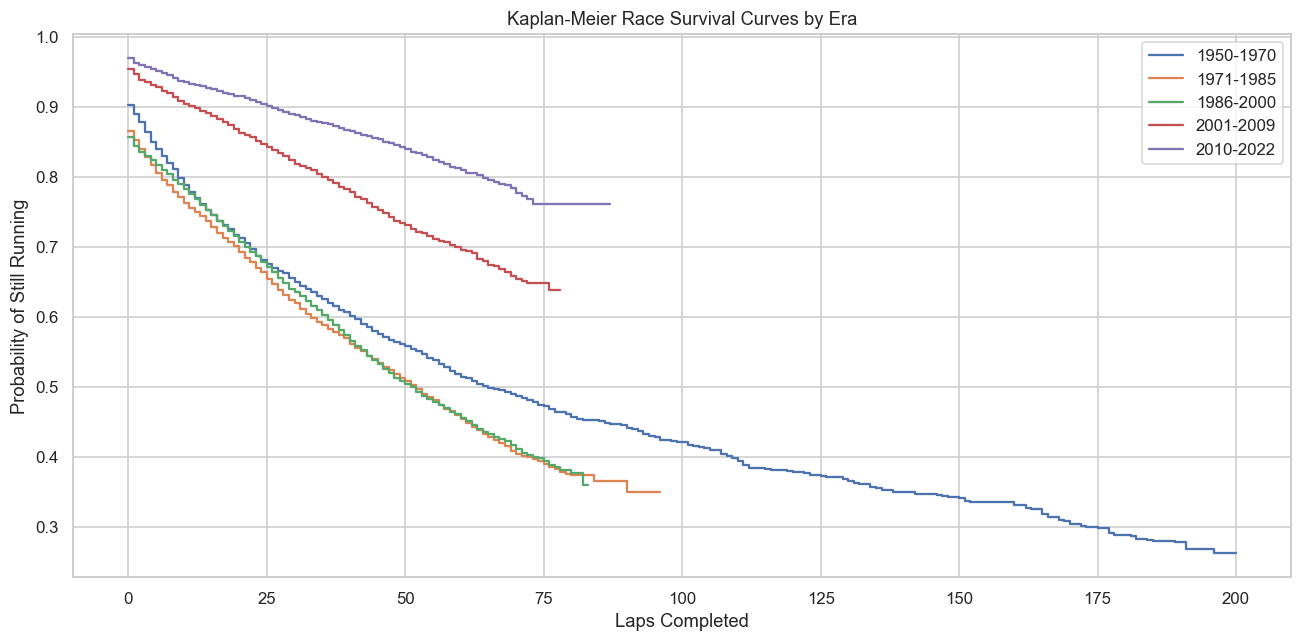

Log-rank test statistic, 1950-1970 vs 2010-2022: 949.83
Log-rank p-value: 1.45e-208


Cox proportional hazards concordance index: 0.620
Logistic regression DNF baseline ROC-AUC: 0.657
DNF rate by era


,era,dnf_rate,dnfs,entries
0,1950-1970,0.532,2348,4414
1,1971-1985,0.561,3406,6070
2,1986-2000,0.559,3669,6569
3,2001-2009,0.312,1019,3270
4,2010-2022,0.189,965,5097


Cox model hazard ratios


,hazard_ratio,p
covariate,,
modern_era,0.329,0.0
grid_bucket_top10,1.391,0.0
grid_bucket_midfield,1.735,0.0
grid_bucket_backmarker,2.103,0.0
constructor_tier_other,1.108,0.0


In [5]:
survival_data = race_results.copy()
survival_data["laps_completed"] = pd.to_numeric(survival_data["laps"], errors="coerce").fillna(0).astype(int)
survival_data["total_laps"] = survival_data.groupby("raceId")["laps_completed"].transform("max")
survival_data = survival_data[survival_data["total_laps"] > 0].copy()

survival_data["era"] = pd.cut(
    survival_data["year"],
    bins=[1949, 1970, 1985, 2000, 2009, 2022],
    labels=["1950-1970", "1971-1985", "1986-2000", "2001-2009", "2010-2022"]
)

era_dnf = survival_data.groupby("era", observed=True)["is_dnf"].agg(["mean", "sum", "count"]).reset_index()
era_dnf.columns = ["era", "dnf_rate", "dnfs", "entries"]

early = survival_data[survival_data["era"] == "1950-1970"]
modern = survival_data[survival_data["era"] == "2010-2022"]
logrank = logrank_test(
    early["laps_completed"], modern["laps_completed"],
    event_observed_A=early["is_dnf"], event_observed_B=modern["is_dnf"]
)

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(12, 6))
for era in survival_data["era"].cat.categories:
    subset = survival_data[survival_data["era"] == era]
    kmf.fit(subset["laps_completed"], event_observed=subset["is_dnf"], label=str(era))
    kmf.plot_survival_function(ax=ax, ci_show=False)
ax.set_title("Kaplan-Meier Race Survival Curves by Era")
ax.set_xlabel("Laps Completed")
ax.set_ylabel("Probability of Still Running")
plt.tight_layout()
plt.show()

cox_data = survival_data[["laps_completed", "is_dnf", "year", "grid", "constructorId"]].dropna().copy()
cox_data = cox_data[(cox_data["laps_completed"] > 0) & (cox_data["grid"] > 0) & (cox_data["grid"] <= 30)]
cox_data["grid_bucket"] = pd.cut(
    cox_data["grid"],
    bins=[0, 3, 10, 20, 30],
    labels=["front_row", "top10", "midfield", "backmarker"]
)

top_constructors = set(cox_data["constructorId"].value_counts().head(15).index)
cox_data["constructor_tier"] = np.where(cox_data["constructorId"].isin(top_constructors), "major", "other")
cox_data["modern_era"] = (cox_data["year"] >= 2010).astype(int)
cox_model_data = pd.get_dummies(
    cox_data[["laps_completed", "is_dnf", "grid_bucket", "constructor_tier", "modern_era"]],
    columns=["grid_bucket", "constructor_tier"],
    drop_first=True,
    dtype=int
)

cox_model = CoxPHFitter()
cox_model.fit(cox_model_data, duration_col="laps_completed", event_col="is_dnf")
cox_summary = cox_model.summary[["exp(coef)", "p"]].rename(columns={"exp(coef)": "hazard_ratio"}).round(3)

logit = LogisticRegression(max_iter=1000)
X_logit = cox_model_data.drop(columns=["laps_completed", "is_dnf"]).values
y_logit = cox_model_data["is_dnf"].values
logit_auc = cross_val_score(logit, X_logit, y_logit, cv=cv, scoring="roc_auc").mean()

print(f"Log-rank test statistic, 1950-1970 vs 2010-2022: {logrank.test_statistic:.2f}")
print(f"Log-rank p-value: {logrank.p_value:.2e}")
print(f"Cox proportional hazards concordance index: {cox_model.concordance_index_:.3f}")
print(f"Logistic regression DNF baseline ROC-AUC: {logit_auc:.3f}")
print("DNF rate by era")
display(era_dnf.round(3))
print("Cox model hazard ratios")
display(cox_summary)

### RQ3 Interpretation

The survival analysis gives the clearest result in the project. DNF rates are much higher in early and middle F1 eras than in the modern period, and the log-rank test shows that the early and modern survival curves are statistically very different. The Cox model also shows the expected direction: starting farther back on the grid increases DNF hazard compared with starting near the front, while the modern era substantially lowers hazard.

The model's concordance is moderate, not perfect. That is expected because many race failures depend on details not included in this historical dataset, such as component age, weather, tire compound, contact severity, and team-specific strategy. Still, the hazard ratios are interpretable and match the historical pattern that F1 became more reliable over time.

## Final Results Summary

Across the three research questions, the strongest finding is that Formula 1 is highly non-stationary across eras. Reliability, race structure, and strategy patterns change enough that older data should not be treated as interchangeable with modern data.

The clustering analysis finds meaningful season regimes, but adding cluster labels to top-five prediction only gives a small change because year, grid position, driver, constructor, and circuit already capture much of the signal. The pit stop analysis finds interpretable rules around one-stop strategies and later first stops, especially for top-ten finishes. The survival analysis shows the largest effect: modern F1 has much lower DNF hazard, while starting farther back on the grid is associated with higher retirement risk.

If I were extending this project, I would add lap time and tire compound data from a richer modern source like FastF1 or OpenF1. That would make the strategy and survival models more detailed, especially for separating car reliability from driver incidents and race-day context.